# Modelo de Ising 2D con Monte Carlo (Metropolis)

## Hamiltoniano
El Hamiltoniano del modelo de Ising en una red cuadrada de $L \times L$ es:

$$
E = -J \sum_{\langle i,j \rangle} s_i s_j, 
\qquad s_i = \pm 1
$$

donde la suma $\langle i,j \rangle$ recorre **pares de espines vecinos**.

---

## Magnetización
La magnetización total:

$$
M = \sum_i s_i ,
m = \frac{M}{N}, \qquad N=L^2.
$$

---

## Condición de balance detallado
En Monte Carlo, la probabilidad de transición $W(C \to C')$ entre configuraciones $C$ y $C'$ debe cumplir:

$$
\frac{W(C \to C')}{W(C' \to C)} 
= \exp\!\left(-\frac{\Delta E}{k_B T}\right),
$$

donde $\Delta E = E(C') - E(C)$.

---

## Regla de aceptación de Metropolis
Una manera de garantizar el balance detallado es usar:

$$
P_{\text{aceptar}}(\Delta E) = 
\begin{cases}
1, & \Delta E \leq 0, \\
\exp\!\left(-\dfrac{\Delta E}{k_B T}\right), & \Delta E > 0.
\end{cases}
$$

---

## Algoritmo paso a paso

1. Seleccionar un espín $s_i$ al azar.  
2. Calcular el cambio de energía si se voltea:

   $$
   \Delta E = 2 J s_i \sum_{j \in \text{vecinos}(i)} s_j .
   $$

3. Generar un número aleatorio $r \in [0,1)$.  
4. Aplicar las reglas:

   - **if** $\Delta E \leq 0 \quad \Rightarrow \quad s_i \to -s_i$  
   - **else if** $r < \exp\!\left(-\dfrac{\Delta E}{k_B T}\right) \quad \Rightarrow \quad s_i \to -s_i$  
   - **else**: $s_i$ no cambia.

---



In [1]:
import matplotlib.pyplot as plt 
import scienceplots 
import numpy as np
plt.style.use(['science', 'notebook', 'grid'])

In [2]:
import numpy as np

x = np.linspace(0, 10, 100)
print(x)

[ 0.          0.1010101   0.2020202   0.3030303   0.4040404   0.50505051
  0.60606061  0.70707071  0.80808081  0.90909091  1.01010101  1.11111111
  1.21212121  1.31313131  1.41414141  1.51515152  1.61616162  1.71717172
  1.81818182  1.91919192  2.02020202  2.12121212  2.22222222  2.32323232
  2.42424242  2.52525253  2.62626263  2.72727273  2.82828283  2.92929293
  3.03030303  3.13131313  3.23232323  3.33333333  3.43434343  3.53535354
  3.63636364  3.73737374  3.83838384  3.93939394  4.04040404  4.14141414
  4.24242424  4.34343434  4.44444444  4.54545455  4.64646465  4.74747475
  4.84848485  4.94949495  5.05050505  5.15151515  5.25252525  5.35353535
  5.45454545  5.55555556  5.65656566  5.75757576  5.85858586  5.95959596
  6.06060606  6.16161616  6.26262626  6.36363636  6.46464646  6.56565657
  6.66666667  6.76767677  6.86868687  6.96969697  7.07070707  7.17171717
  7.27272727  7.37373737  7.47474747  7.57575758  7.67676768  7.77777778
  7.87878788  7.97979798  8.08080808  8.18181818  8

In [3]:
magnetizations, energies = np.load('ising/magnetizaciones.npy'), np.load('ising/energias.npy')

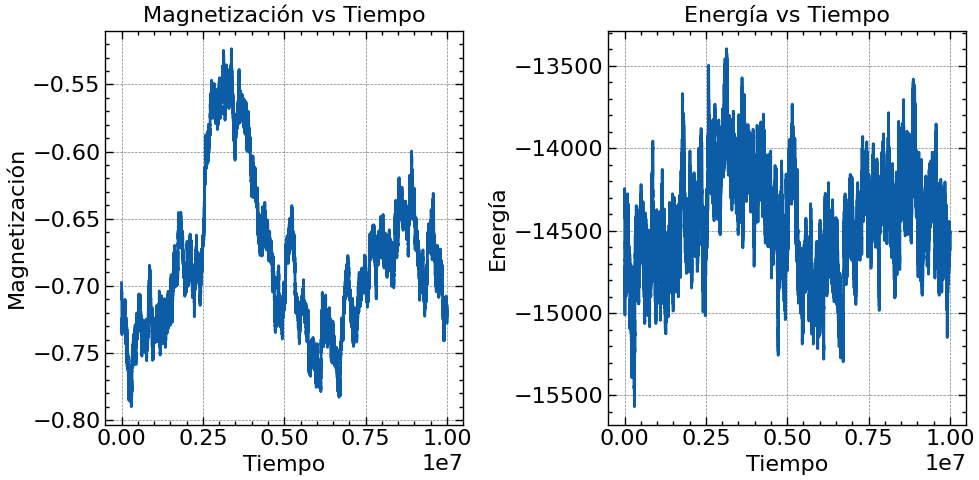

In [4]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(magnetizations)
plt.title('Magnetización vs Tiempo')
plt.xlabel('Tiempo')
plt.ylabel('Magnetización')

plt.subplot(1, 2, 2)
plt.plot(energies)
plt.title('Energía vs Tiempo')
plt.xlabel('Tiempo')
plt.ylabel('Energía')

plt.tight_layout()
plt.show()

# 🔹 Cumulante de Binder en el modelo de Ising 2D

El **cumulante de Binder** mide la **forma de la distribución de la magnetización**.

En cada temperatura, a partir de la serie temporal de magnetización por espín \( m_t = M_t / N \), se calculan los momentos estadísticos:

$$
\langle m^2 \rangle = \frac{1}{n}\sum_t m_t^2, \qquad
\langle m^4 \rangle = \frac{1}{n}\sum_t m_t^4.
$$

El **cumulante reducido de cuarto orden** se define como:

$$
U_4(T, L) = 1 - \frac{\langle m^4 \rangle}{3\,\langle m^2 \rangle^2}.
$$

---

## Interpretación física

- **Temperaturas bajas** (\(T < T_c\)):  
  El sistema está magnetizado, la distribución \(P(m)\) es **bimodal** (dos picos en ±m₀).  
  $$U_4 \approx \frac{2}{3} \approx 0.666.$$

- **Temperaturas altas** (\(T > T_c\)):  
  El sistema está desordenado, \(P(m)\) es **gaussiana** centrada en 0.  
  $$\langle m^4 \rangle = 3 \langle m^2 \rangle^2 \Rightarrow U_4 \approx 0.$$

- **Cerca de \(T_c\)**:  
  La distribución cambia de bimodal a unimodal →  
  \(U_4(T, L)\) **decrece suavemente** entre 2/3 y 0.

---

## Cómo se usa para estimar \(T_c\)

1. Simula varias redes con diferentes tamaños \(L\) (por ejemplo 16, 32, 64, 128).  
2. Calcula \(U_4(T, L)\) para un rango de temperaturas \(T\).  
3. Grafica \(U_4(T, L)\) vs \(T\).

El **punto de cruce** de las curvas para distintos tamaños \(L\) marca el **punto crítico \(T_c\)** en el límite termodinámico.

Este método es **adimensional** y **no requiere calibración** de magnitudes extensivas, por lo que es muy robusto.


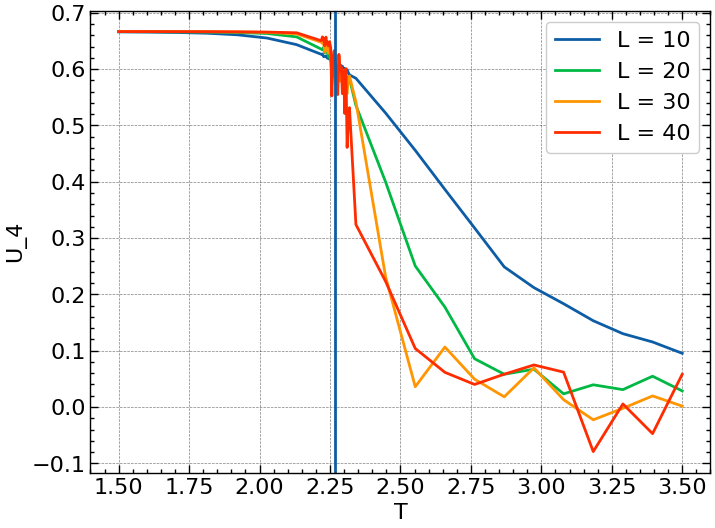

In [5]:
Tc = 2.269185314213
T_coarse = np.linspace(1.5, 3.5, 20)
T_fine = np.linspace(Tc - 0.05, Tc + 0.05, 25)
T_list = np.unique(np.concatenate([T_coarse, T_fine]))

# for L in ['256', '128', '64', '32', '16']:
for L in ['10', '20', '30', '40']:
    magnetizations = np.load('ising/U_4_'+L+'.npy')
    plt.plot(T_list, magnetizations, label = 'L = '+L)
plt.axvline(x = 2.269)
plt.xlabel('T')
# plt.ylim(0,0.7)
# plt.xlim(2.25,2.3)
plt.ylabel('U_4')
plt.legend()
plt.show()

# KURAMOTO

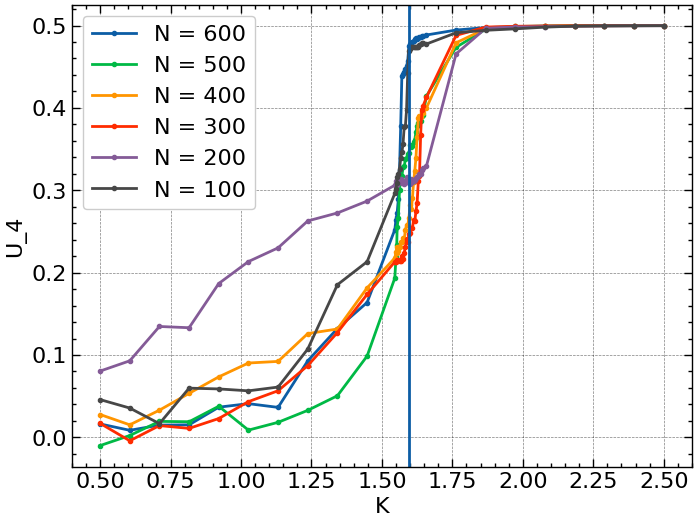

In [6]:
Kc = 2 * 1 * np.sqrt(2/np.pi)  # umbral teórico para g(ω) ~ N(0, σ^2)
T_coarse = np.linspace(0.5, 2.5, 20)
T_fine = np.linspace(Kc - 0.05, Kc + 0.05, 25)
T_list = np.unique(np.concatenate([T_coarse, T_fine]))

# for L in ['256', '128', '64', '32', '16']:
# for L in ['10', '20', '30', '40']:
for L in ['600','500', '400', '300', '200', '100']:
    magnetizations = np.load('kuramoto/U_4_'+L+'.npy')
    plt.plot(T_list, magnetizations, label = 'N = '+L, marker='.')
plt.axvline(x = Kc)
plt.xlabel('K')
# plt.ylim(0,0.7)
# plt.xlim(2.25,2.3)
plt.ylabel('U_4')
plt.legend()
plt.show()

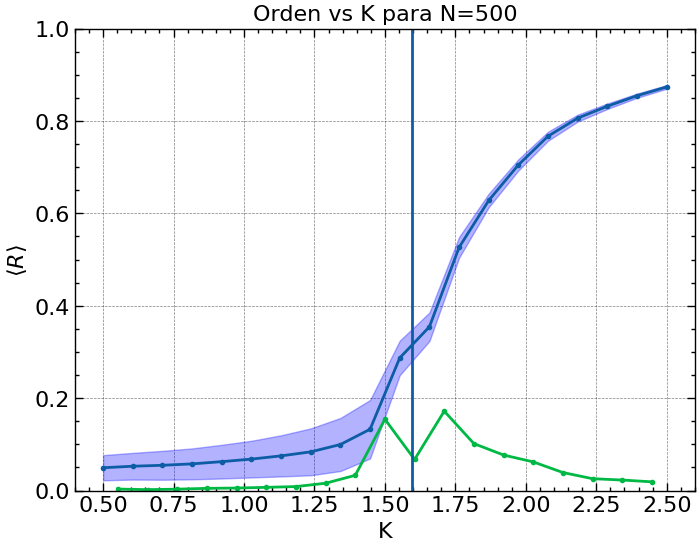

In [17]:
Kc = 2 * 1 * np.sqrt(2/np.pi)  # umbral teórico para g(ω) ~ N(0, σ^2)
T_coarse = np.linspace(0.5, 2.5, 20)
T_fine = np.linspace(Kc - 0.05, Kc + 0.05, 25)
T_list = np.unique(np.concatenate([T_coarse, T_fine]))
y = np.load('kuramoto/R_mean_N500.npy')
std = np.load('kuramoto/R_std_N500.npy')


n_puntos = len(T_coarse)
T_uniform = np.linspace(T_list.min(), T_list.max(), n_puntos)

# Interpola y(T) al nuevo eje uniforme
y = np.interp(T_uniform, T_list, y)
std = np.interp(T_uniform, T_list, std)
T_list = T_uniform

plt.plot(T_list, y, marker='.')
plt.fill_between(T_list, y - std, y + std, color='blue', alpha=0.3, label='±1σ')
plt.plot(T_list[:-1] + np.mean(np.abs(np.diff(T_list)))/2, np.diff(y), marker='.')
plt.xlabel('K')
plt.ylim(0,1)
plt.ylabel(r'$\langle R \rangle$')
plt.axvline(x = Kc)
plt.title('Orden vs K para N=500')
plt.show()

Text(0, 0.5, 'P(X = k)')

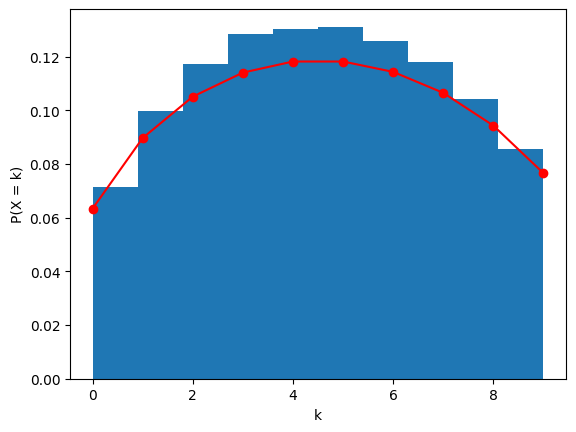

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import betabinom

def plot_beta_binomial(n, alpha, beta):
    k = np.arange(0, n)                 # posibles valores 0,1,...,n
    pmf = betabinom.pmf(k, n, alpha, beta)  # función de masa de probabilidad
    probs = pmf / pmf.sum()

    plt.figure()
    plt.stem(k, pmf, basefmt=" ")
    dist_theory = betabinom.pmf(np.arange(t), t, alpha, beta)
    dist_theory /= dist_theory.sum()
    plt.plot(np.arange(t), dist_theory, 'ro-', label='Teoría')
    plt.xlabel("k")
    plt.ylabel("P(X = k)")
    plt.title(f"Distribución Beta-Binomial (n={n}, α={alpha}, β={beta})")
    plt.grid(True, alpha=0.3)
    plt.show()

    return probs

import numpy as np
import math
from numba import njit

@njit
def beta_binomial_probs(n, alpha, beta):
    """
    Aproxima betabinom.pmf(k, n, alpha, beta) para k = 0,1,...,n-1
    y normaliza para que sume 1 (truncada en k = n-1, igual que tu código).
    """
    probs = np.empty(n, dtype=np.float64)  # k = 0,...,n-1
    N = n                                  # parámetro 'n' de la beta-binomial

    # log B(alpha, beta)
    log_B0 = math.lgamma(alpha) + math.lgamma(beta) - math.lgamma(alpha + beta)
    log_N_fact = math.lgamma(N + 1)

    for k in range(n):  # k = 0,...,n-1
        # log binom(N, k)
        log_binom = log_N_fact - math.lgamma(k + 1) - math.lgamma(N - k + 1)

        # log B(k+alpha, N-k+beta)
        log_B1 = (math.lgamma(k + alpha)
                  + math.lgamma(N - k + beta)
                  - math.lgamma(N + alpha + beta))

        log_p = log_binom + log_B1 - log_B0
        probs[k] = math.exp(log_p)

    # Normalizar por seguridad (igual que pmf / pmf.sum())
    s = 0.0
    for i in range(n):
        s += probs[i]
    for i in range(n):
        probs[i] /= s

    return probs



if __name__ == "__main__":
    # Ejemplo: t pasos -> eliges t' en {0,...,t-1}
    t = 10
    alpha = 1.5
    beta = 1.6

    # probs = plot_beta_binomial(t, alpha, beta)
    probs = beta_binomial_probs(t, alpha, beta)

     # Muestreo usando las probabilidades calculadas


nums = []
for _ in range(100000):
    num = np.random.choice(np.arange(t), p=probs)
    nums.append(num)
plt.hist(nums, bins=t, density=True)
dist_theory = betabinom.pmf(np.arange(t), t, alpha, beta)
dist_theory /= dist_theory.sum()
plt.plot(np.arange(t), dist_theory, 'ro-', label='Teoría')
plt.xlabel('k')
plt.ylabel('P(X = k)')

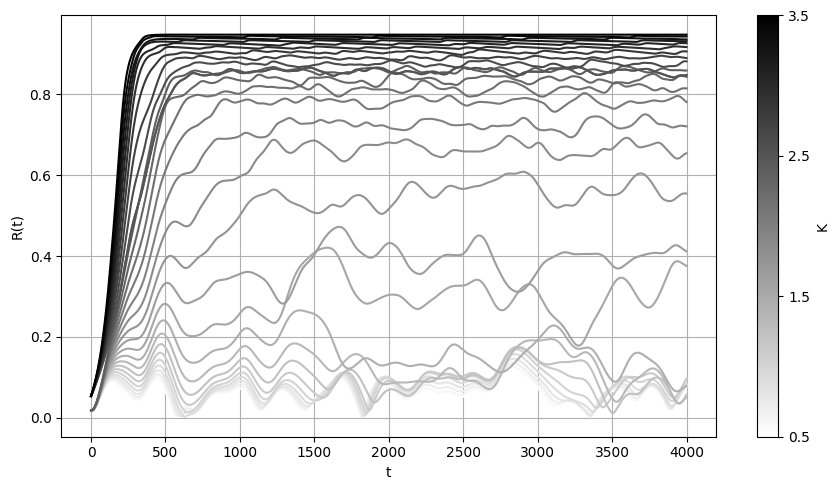

In [20]:
import numpy as np
import matplotlib.pyplot as plt

k_values = np.concatenate((np.linspace(0.5, 2.5, 20),
                           np.linspace(2.5, 3.5, 10)))

# Colormap invertido
cmap = plt.get_cmap('gray_r')

fig, ax = plt.subplots(figsize=(9, 5))

# Normalización para mapear k -> colorbar
norm = plt.Normalize(vmin=k_values.min(), vmax=k_values.max())

for k in k_values:
    y = np.load(f'kuramoto/R_values/R_{k}.npy')[:4000]
    color = cmap(norm(k))  # ahora el color depende de k
    ax.plot(y, color=color)

ax.set_xlabel('t')
ax.set_ylabel('R(t)')
ax.grid(True)

# Barra de colores basada en K
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('K')

# Tics bonitos para K
cbar.set_ticks([0.5, 1.5, 2.5, 3.5])
cbar.set_ticklabels(['0.5', '1.5', '2.5', '3.5'])

plt.tight_layout()
plt.show()
